# Term Project CEU: Time Series Forecasting
Professor: Henrika Langen

## Forecasting Hourly Appliance Energy Consumption: 
The objective of this project is to forecaset hourly appliance energy consumption using a selection of univariate and multivariate time series models. Namely, I will implement and compare the following models' performance and accuracy. 

- SARIMAX
- Prophet: 
- Neural Network

## Data Cleaning

### Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from calendar import month_name
import seaborn as sns

# forecasting libraries
from prophet import Prophet
import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Neural Network libraries
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout
from keras import Input
from keras.optimizers import Adam

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.stattools import adfuller
from prophet.plot import add_changepoints_to_plot



# Configuration
import warnings
warnings.filterwarnings("ignore")

/Users/amh/.venvs/time_series/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('energydata_complete.csv')
df

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.890000,47.596667,19.200000,44.790000,19.790000,44.730000,19.000000,...,17.033333,45.5300,6.600000,733.5,92.000000,7.000000,63.000000,5.300000,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.890000,46.693333,19.200000,44.722500,19.790000,44.790000,19.000000,...,17.066667,45.5600,6.483333,733.6,92.000000,6.666667,59.166667,5.200000,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.890000,46.300000,19.200000,44.626667,19.790000,44.933333,18.926667,...,17.000000,45.5000,6.366667,733.7,92.000000,6.333333,55.333333,5.100000,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.890000,46.066667,19.200000,44.590000,19.790000,45.000000,18.890000,...,17.000000,45.4000,6.250000,733.8,92.000000,6.000000,51.500000,5.000000,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.890000,46.333333,19.200000,44.530000,19.790000,45.000000,18.890000,...,17.000000,45.4000,6.133333,733.9,92.000000,5.666667,47.666667,4.900000,10.084097,10.084097
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19730,2016-05-27 17:20:00,100,0,25.566667,46.560000,25.890000,42.025714,27.200000,41.163333,24.700000,...,23.200000,46.7900,22.733333,755.2,55.666667,3.333333,23.666667,13.333333,43.096812,43.096812
19731,2016-05-27 17:30:00,90,0,25.500000,46.500000,25.754000,42.080000,27.133333,41.223333,24.700000,...,23.200000,46.7900,22.600000,755.2,56.000000,3.500000,24.500000,13.300000,49.282940,49.282940
19732,2016-05-27 17:40:00,270,10,25.500000,46.596667,25.628571,42.768571,27.050000,41.690000,24.700000,...,23.200000,46.7900,22.466667,755.2,56.333333,3.666667,25.333333,13.266667,29.199117,29.199117
19733,2016-05-27 17:50:00,420,10,25.500000,46.990000,25.414000,43.036000,26.890000,41.290000,24.700000,...,23.200000,46.8175,22.333333,755.2,56.666667,3.833333,26.166667,13.233333,6.322784,6.322784


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9  

In [4]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)


In [5]:
df.columns

Index(['Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4',
       'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9',
       'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility',
       'Tdewpoint', 'rv1', 'rv2'],
      dtype='object')

In [6]:
column_rename_map = {
    'Appliances': 'appliances_energy_wh',
    'lights': 'lights_energy_wh',
    'T1': 'temp_kitchen_C',
    'RH_1': 'humidity_kitchen_pct',
    'T2': 'temp_living_C',
    'RH_2': 'humidity_living_pct',
    'T3': 'temp_laundry_C',
    'RH_3': 'humidity_laundry_pct',
    'T4': 'temp_office_C',
    'RH_4': 'humidity_office_pct',
    'T5': 'temp_bathroom_C',
    'RH_5': 'humidity_bathroom_pct',
    'T6': 'temp_outside_north_C',
    'RH_6': 'humidity_outside_north_pct',
    'T7': 'temp_ironing_C',
    'RH_7': 'humidity_ironing_pct',
    'T8': 'temp_teenager_C',
    'RH_8': 'humidity_teenager_pct',
    'T9': 'temp_parents_C',
    'RH_9': 'humidity_parents_pct',
    'T_out': 'temp_outdoor_C',
    'Press_mm_hg': 'pressure_mmHg',
    'RH_out': 'humidity_outdoor_pct',
    'Windspeed': 'windspeed_m_s',
    'Visibility': 'visibility_km',
    'Tdewpoint': 'dewpoint_C',
    'rv1': 'random_var1',
    'rv2': 'random_var2'
}
df.rename(columns=column_rename_map, inplace=True)

In [7]:
# Check datetime range and frequency
print("Date range:", df.index.min(), "to", df.index.max())
print("Frequency:", df.index.freq)

Date range: 2016-01-11 17:00:00 to 2016-05-27 18:00:00
Frequency: None


In [8]:
# Resample 10 minute intervals to hourly resolution using mean
df_hourly = df.resample('H').mean()

# Check for successful resampling
df_hourly.head()


,appliances_energy_wh,lights_energy_wh,temp_kitchen_C,humidity_kitchen_pct,temp_living_C,humidity_living_pct,temp_laundry_C,humidity_laundry_pct,temp_office_C,humidity_office_pct,...,temp_parents_C,humidity_parents_pct,temp_outdoor_C,pressure_mmHg,humidity_outdoor_pct,windspeed_m_s,visibility_km,dewpoint_C,random_var1,random_var2
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,55.000000,35.000000,19.890000,46.502778,19.200000,44.626528,19.790000,44.897778,18.932778,45.738750,...,17.016667,45.446667,6.308333,733.750000,92.000000,6.166667,53.416667,5.050000,26.823044,26.823044
2016-01-11 18:00:00,176.666667,51.666667,19.897778,45.879028,19.268889,44.438889,19.770000,44.863333,18.908333,46.066667,...,16.981667,45.290000,5.941667,734.266667,91.583333,5.416667,40.000000,4.658333,22.324206,22.324206
2016-01-11 19:00:00,173.333333,25.000000,20.495556,52.805556,19.925556,46.061667,20.052222,47.227361,18.969444,47.815556,...,16.902222,45.311389,6.000000,734.791667,89.750000,6.000000,40.000000,4.391667,33.734932,33.734932
2016-01-11 20:00:00,125.000000,35.000000,20.961111,48.453333,20.251111,45.632639,20.213889,47.268889,19.190833,49.227917,...,16.890000,45.118889,6.000000,735.283333,87.583333,6.000000,40.000000,4.016667,25.679642,25.679642
2016-01-11 21:00:00,103.333333,23.333333,21.311667,45.768333,20.587778,44.961111,20.373333,46.164444,19.425556,47.918889,...,16.890000,44.807778,5.833333,735.566667,87.416667,6.000000,40.000000,3.816667,18.826274,18.826274


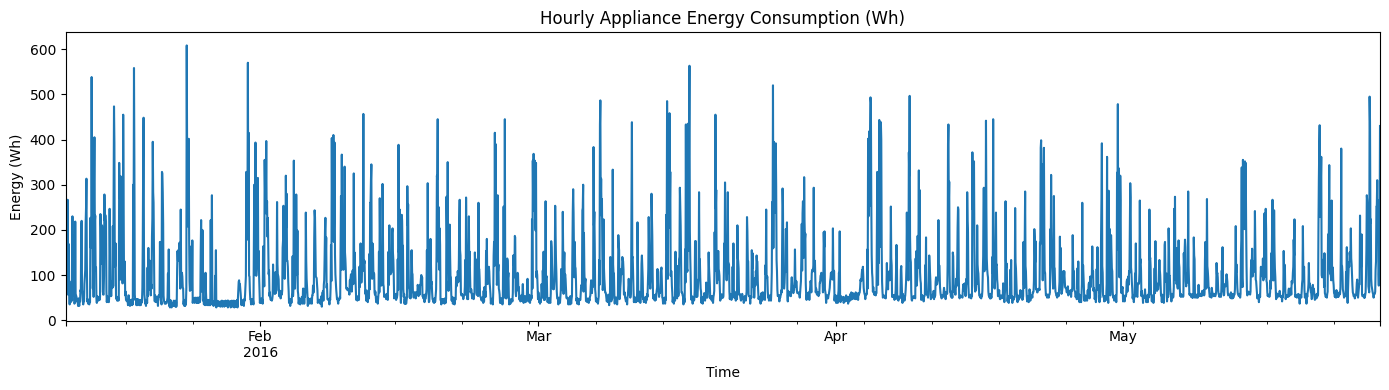

In [9]:
plt.figure(figsize=(14, 4))
df_hourly['appliances_energy_wh'].plot()
plt.title('Hourly Appliance Energy Consumption (Wh)')
plt.ylabel('Energy (Wh)')
plt.xlabel('Time')
plt.tight_layout()
plt.show()


## Initial Data Visualisation

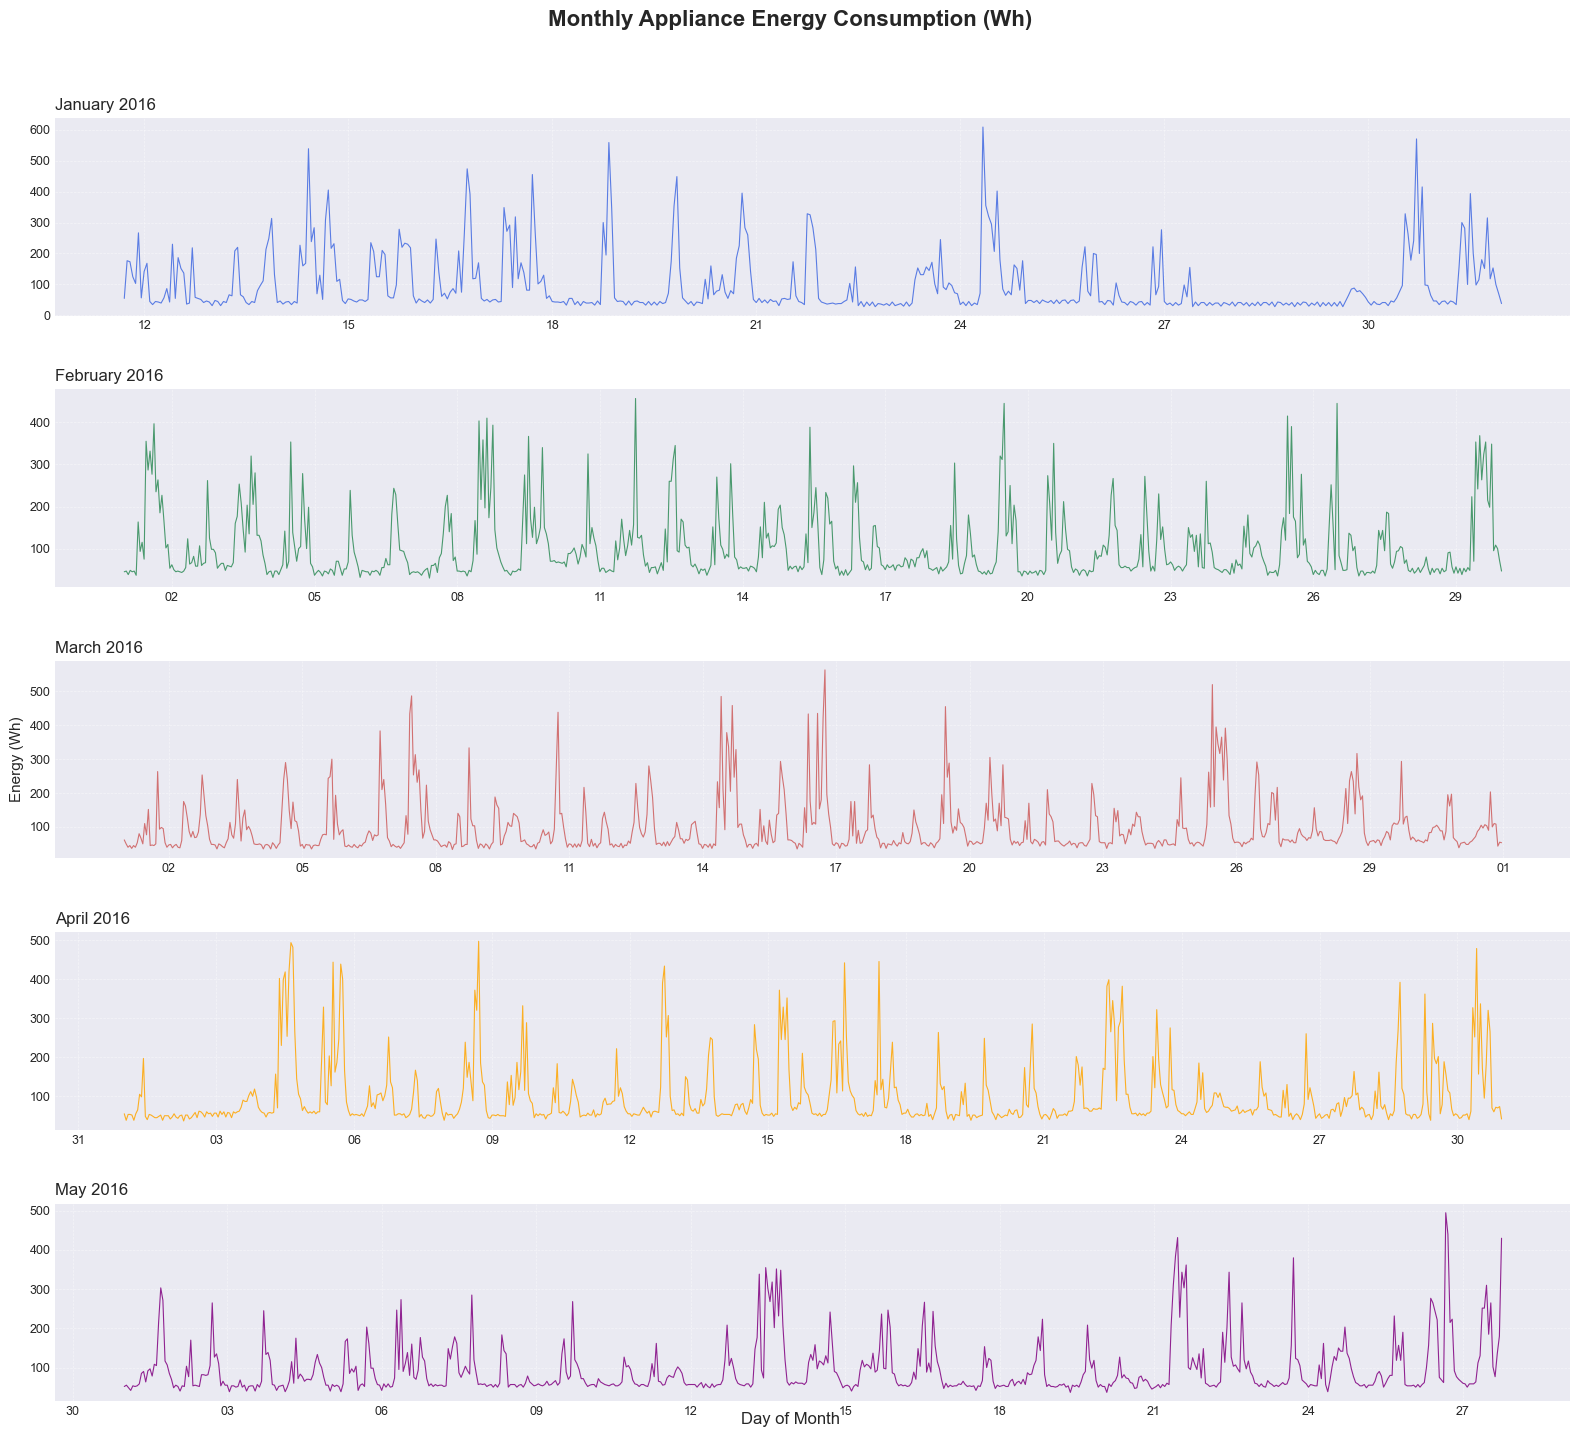

In [10]:
# Style improvements
sns.set_context("notebook", font_scale=1.1)
plt.style.use('seaborn-v0_8-darkgrid')
plt.style.use("seaborn-v0_8-muted")  # More modern look than 'pastel'

# Add 'month' column if not already present
if 'month' not in df_hourly.columns:
    df_hourly['month'] = df_hourly.index.month

# Create figure and axes
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(16, 14), sharex=False)
fig.suptitle('Monthly Appliance Energy Consumption (Wh)', y=1.02, fontsize=16, fontweight='bold')

# Get list of months in order
months_in_data = sorted(df_hourly['month'].unique())

# Define a list of distinct colors for each month
colors = ['royalblue', 'seagreen', 'indianred', 'orange', 'purple']

# Loop through each month to plot
for i, month in enumerate(months_in_data):
    ax = axes[i]
    month_data = df_hourly[df_hourly['month'] == month]
    
    # Plotting with a different color for each month
    ax.plot(month_data.index, month_data['appliances_energy_wh'], color=colors[i], linewidth=0.8, alpha=0.85)
    
    # Title per subplot
    ax.set_title(f'{month_name[month]} 2016', fontsize=12, loc='left')
    
    # Format x-axis ticks
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d'))
    ax.tick_params(axis='x', labelsize=9)
    ax.tick_params(axis='y', labelsize=9)
    
    # Add y-label to middle plot only
    if i == len(months_in_data) // 2:
        ax.set_ylabel('Energy (Wh)', fontsize=11)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Cleaner grid
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

# Adjust layout
plt.tight_layout(h_pad=2.0)

# Add common x-label
fig.text(0.5, 0.01, 'Day of Month', ha='center', fontsize=12)

# Show the plot
plt.show()


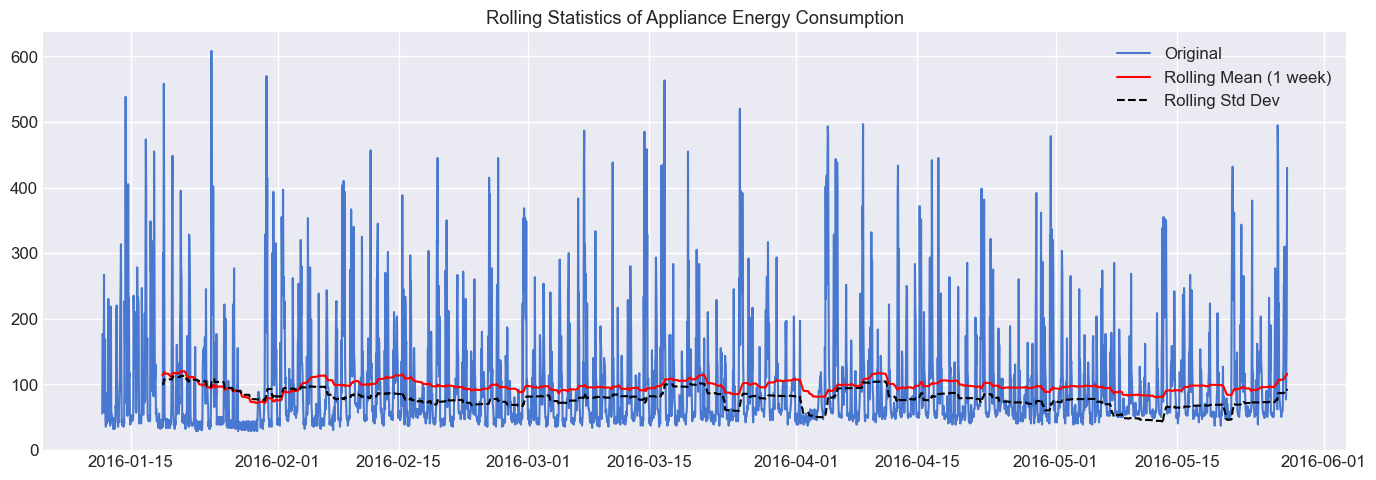

In [11]:
##  2.2 Rolling Mean & Standard Deviation (to inspect trend/variance)
rolling_window = 24 * 7  # 1 week

rolling_mean = df_hourly['appliances_energy_wh'].rolling(window=rolling_window).mean()
rolling_std = df_hourly['appliances_energy_wh'].rolling(window=rolling_window).std()

plt.figure(figsize=(14, 5))
plt.style.use('seaborn-v0_8-darkgrid')
plt.plot(df_hourly['appliances_energy_wh'], label='Original')
plt.plot(rolling_mean, color='red', label='Rolling Mean (1 week)')
plt.plot(rolling_std, color='black', linestyle='--', label='Rolling Std Dev')
plt.title('Rolling Statistics of Appliance Energy Consumption')
plt.legend()
plt.tight_layout()
plt.show()


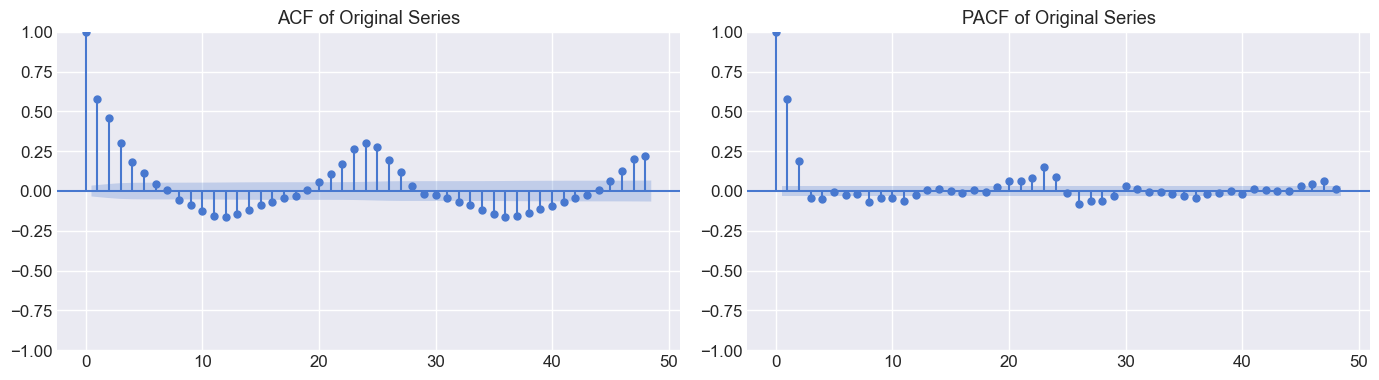

In [12]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for the original series
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df_hourly['appliances_energy_wh'], lags=48, ax=axes[0])
plot_pacf(df_hourly['appliances_energy_wh'], lags=48, ax=axes[1])
axes[0].set_title('ACF of Original Series')
axes[1].set_title('PACF of Original Series')
plt.tight_layout()
plt.show()


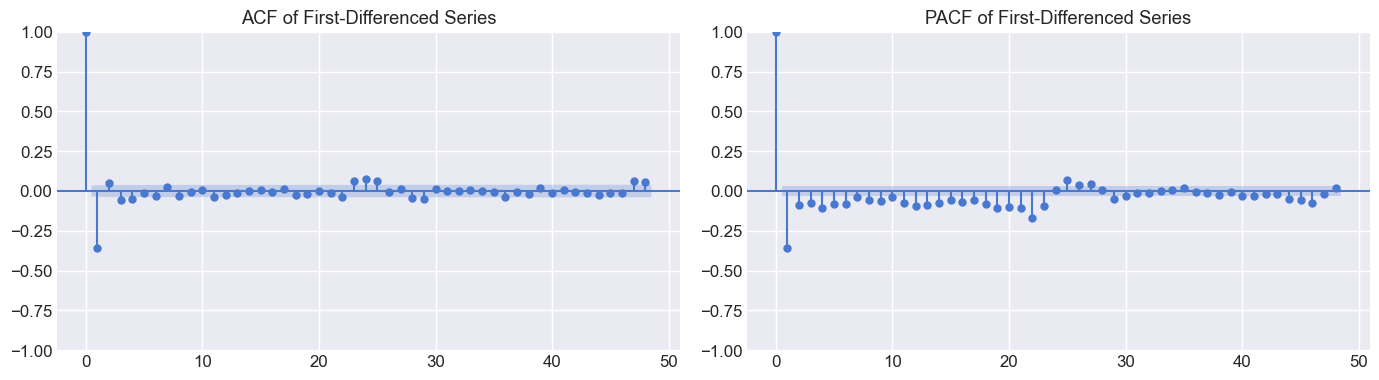

In [13]:
# First difference
diff_series = df_hourly['appliances_energy_wh'].diff().dropna()

# Plot ACF and PACF for differenced series
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(diff_series, lags=48, ax=axes[0])
plot_pacf(diff_series, lags=48, ax=axes[1])
axes[0].set_title('ACF of First-Differenced Series')
axes[1].set_title('PACF of First-Differenced Series')
plt.tight_layout()
plt.show()


#### ACF and PACF of the Original and First-Differenced `Appliances` Series

To evaluate the stationarity and autocorrelation structure of the target variable, we examine the autocorrelation function (ACF) and partial autocorrelation function (PACF) of both the original and first-differenced `Appliances` energy series.

**Original Series:**
- The ACF shows a strong spike at lag 1, followed by a gradually decaying sinusoidal pattern.
- Clear autocorrelation is visible at multiples of 24, consistent with **daily seasonality** in hourly data.
- The PACF displays a sharp drop after lag 1, suggesting an **AR(1)** or **AR(2)** structure may be sufficient in the non-seasonal part.
- The persistence of autocorrelation over many lags suggests the series is **non-stationary**.

**First-Differenced Series:**
- After differencing, the ACF drops off much more quickly and most values fall within the 95% confidence bands.
- This indicates the series is now **approximately stationary**.
- The PACF retains a significant negative spike at lag 1 and small residual structure, consistent with a possible **ARMA(1,1)** form.

These observations support the decision to use a **SARIMAX model with seasonal components (m=24)** and modest non-seasonal AR/MA terms.


In [14]:
# 2.3 Augmented Dickey-Fuller Test / Stationarity Check
adf_result = adfuller(df_hourly['appliances_energy_wh'].dropna())
print("Augmented Dickey-Fuller Test Results:")
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
for key, value in adf_result[4].items():
    print(f"Critical Value ({key}): {value}")


Augmented Dickey-Fuller Test Results:
ADF Statistic: -8.948888280256933
p-value: 8.833753129592069e-15
Critical Value (1%): -3.432357502010421
Critical Value (5%): -2.862426994644342
Critical Value (10%): -2.567242166152283


### Stationarity Check: Augmented Dickey-Fuller (ADF) Test

To assess whether the `appliances_energy_wh` time series is stationary, we conducted the Augmented Dickey-Fuller (ADF) test.

**Results:**
- ADF Statistic = **-8.95**
- p-value = **8.83e-15**
- Critical values:
  - 1%: -3.43
  - 5%: -2.86
  - 10%: -2.57

**Interpretation:**
Since the ADF test statistic is **well below** all critical values and the p-value is **much less than 0.05**, we reject the null hypothesis of a unit root.  
This indicates that the series is **stationary**, and does **not require differencing** for models like SARIMAX or Prophet.


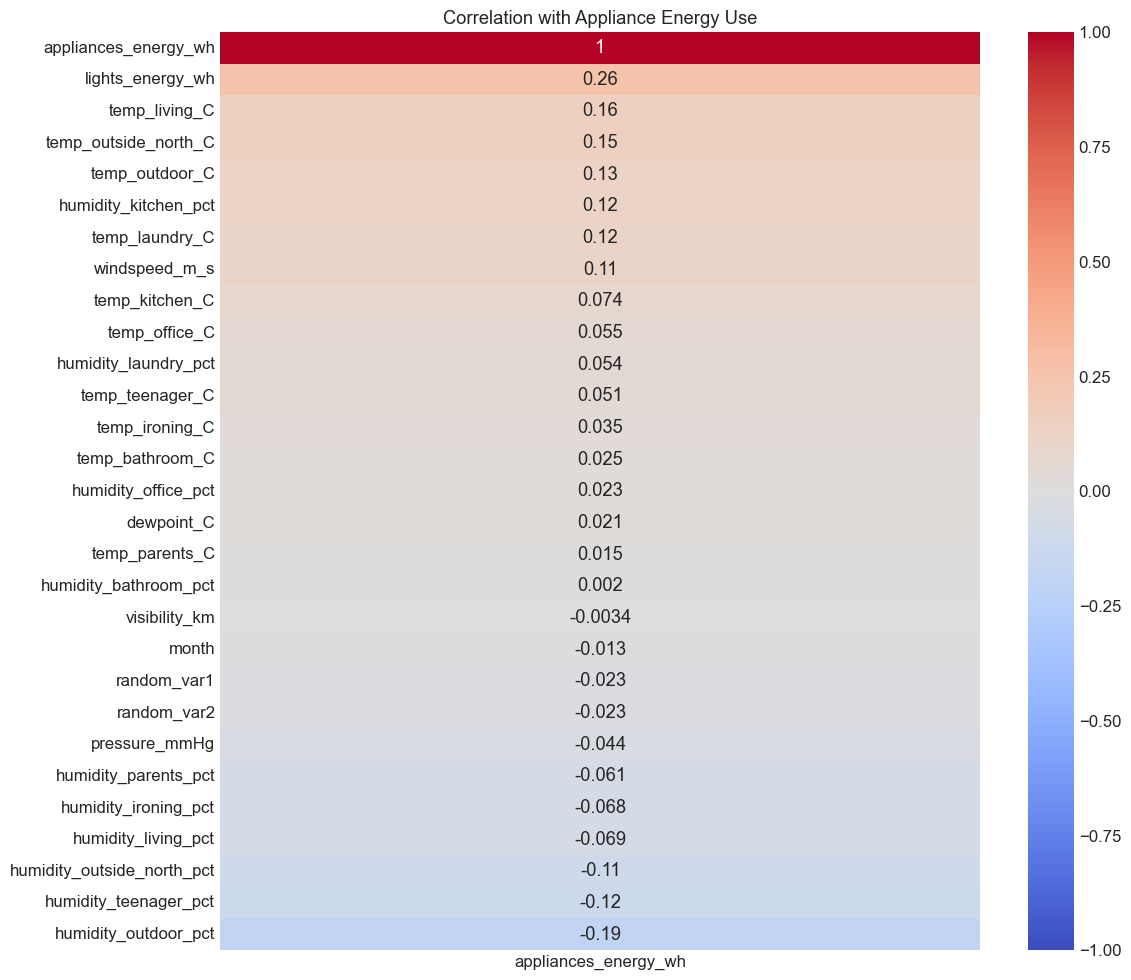

In [15]:
### 2.4 Correlation Analysis
plt.figure(figsize=(12, 10))
correlation = df_hourly.corr()
sns.heatmap(correlation[['appliances_energy_wh']].sort_values(by='appliances_energy_wh', ascending=False), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation with Appliance Energy Use')
plt.tight_layout()
plt.show()


### Exploratory Data Analysis Summary
The EDA revealed daily and weekly seasonality in hourly energy consumption. The rolling mean and standard deviation plots suggest strong cyclical patterns. The ADF test (p-value < 0.05) indicates stationarity of the hourly series. These patterns motivate the use of seasonal models like SARIMAX and Prophet, as well as neural networks to capture potential nonlinear effects.

## Model #1 SARIMAX

In [16]:
# Drop artificial/random variables 
df_hourly = df_hourly.drop(columns=['random_var1', 'random_var2'], errors='ignore')


In [17]:
# Define target and potential exogenous variables
target_col = 'appliances_energy_wh'
exog_vars = ['lights_energy_wh', 'temp_outdoor_C', 'humidity_outdoor_pct', 'pressure_mmHg']

In [18]:
df_hourly.columns

Index(['appliances_energy_wh', 'lights_energy_wh', 'temp_kitchen_C',
       'humidity_kitchen_pct', 'temp_living_C', 'humidity_living_pct',
       'temp_laundry_C', 'humidity_laundry_pct', 'temp_office_C',
       'humidity_office_pct', 'temp_bathroom_C', 'humidity_bathroom_pct',
       'temp_outside_north_C', 'humidity_outside_north_pct', 'temp_ironing_C',
       'humidity_ironing_pct', 'temp_teenager_C', 'humidity_teenager_pct',
       'temp_parents_C', 'humidity_parents_pct', 'temp_outdoor_C',
       'pressure_mmHg', 'humidity_outdoor_pct', 'windspeed_m_s',
       'visibility_km', 'dewpoint_C', 'month'],
      dtype='object')

In [19]:
# Define the split point using integer location indexing
n = len(df_hourly)
train_size = int(n * 0.8)

train = df_hourly.iloc[:train_size]
test = df_hourly.iloc[train_size:]

# Split target and exogenous variables
y_train = train['appliances_energy_wh']
y_test = test['appliances_energy_wh']
X_train = train.drop(columns=['appliances_energy_wh'])
X_test = test.drop(columns=['appliances_energy_wh'])


In [20]:
## Use auto_arima to find optimal parameters
auto_model = pm.auto_arima(
    y_train,
    exogenous=X_train,
    seasonal=True,
    m=24,  # hourly data with daily seasonality
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore'
)

print(auto_model.summary())


                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                 2632
Model:             SARIMAX(1, 0, 1)x(2, 0, 1, 24)   Log Likelihood              -14701.310
Date:                            Fri, 30 May 2025   AIC                          29416.620
Time:                                    16:55:38   BIC                          29457.748
Sample:                                01-11-2016   HQIC                         29431.512
                                     - 04-30-2016                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      2.5503      0.756      3.376      0.001       1.069       4.031
ar.L1          0.7212      0.020   

In [21]:
# Retrieve best order and seasonal_order
order = auto_model.order
seasonal_order = auto_model.seasonal_order

sarimax_model = SARIMAX(
    y_train,
    exog=X_train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(sarimax_model.summary())


                                     SARIMAX Results                                      
Dep. Variable:               appliances_energy_wh   No. Observations:                 2632
Model:             SARIMAX(1, 0, 1)x(2, 0, 1, 24)   Log Likelihood              -14287.543
Date:                            Fri, 30 May 2025   AIC                          28639.087
Time:                                    17:01:13   BIC                          28826.501
Sample:                                01-11-2016   HQIC                         28707.014
                                     - 04-30-2016                                         
Covariance Type:                              opg                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
lights_energy_wh               1.8206      0.224      8.143      0.000       1.382

In [22]:
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess

fourier = CalendarFourier(freq='D', order=3)  # k=3
dp = DeterministicProcess(
    index=y_train.index,
    constant=True,
    order=0,
    additional_terms=[fourier],
    drop=True
)

X_fourier = dp.in_sample()

In [23]:
# Recreate Fourier terms for the test set using the same DeterministicProcess
X_fourier_test = dp.out_of_sample(steps=len(y_test))

# Use the same exogenous vars used in the Fourier training model
exog_vars = [
    'lights_energy_wh',
    'humidity_kitchen_pct',
    'temp_living_C',
    'humidity_living_pct',
    'temp_laundry_C',
    'humidity_laundry_pct',
    'humidity_office_pct',
    'temp_outside_north_C',
    'humidity_outside_north_pct'
    ]

X_exog_train = X_train[exog_vars]
X_fourier_train = dp.in_sample()

# Combine exogenous + Fourier terms for training set
X_full_train = pd.concat([X_exog_train, X_fourier_train], axis=1)

X_exog_test = X_test[exog_vars]

# Combine exogenous + Fourier terms exactly as in training
X_test_fourier = pd.concat([X_exog_test, X_fourier_test], axis=1)
X_test_fourier = X_test_fourier[X_full_train.columns]  # Align column order


In [24]:
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess

fourier = CalendarFourier(freq='D', order=3)
dp = DeterministicProcess(
    index=y_train.index,
    constant=True,
    order=0,
    additional_terms=[fourier],
    drop=True
)

X_fourier_train = dp.in_sample()
X_fourier_test = dp.out_of_sample(steps=len(y_test))


In [25]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarimax_fourier_model = SARIMAX(
    y_train,
    exog=X_full_train,
    order=(1, 0, 1),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(sarimax_fourier_model.summary())


                                SARIMAX Results                                 
Dep. Variable:     appliances_energy_wh   No. Observations:                 2632
Model:                 SARIMAX(1, 0, 1)   Log Likelihood              -14533.576
Date:                  Fri, 30 May 2025   AIC                          29105.151
Time:                          17:01:18   BIC                          29216.771
Sample:                      01-11-2016   HQIC                         29145.570
                           - 04-30-2016                                         
Covariance Type:                    opg                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
lights_energy_wh               2.0864      0.191     10.937      0.000       1.713       2.460
humidity_kitchen_pct           9.5012      1.150      8.264      0.

#### Residual Diagnostics: ACF of SARIMAX Residuals

To evaluate the adequacy of the SARIMAX model, the autocorrelation function (ACF) of its residual was plotted. A well-specified model should produce residuals that resemble white noise — i.e., uncorrelated over time.

The residual ACF plot above shows:
- A single spike at lag 0 (as expected)
- All other autocorrelations fall well within the 95% confidence bounds

This indicates that the SARIMAX model has effectively captured the underlying autocorrelation structure of the `Appliances` time series. No systematic structure remains in the residuals, confirming the statistical adequacy of the model.


<Figure size 800x400 with 0 Axes>

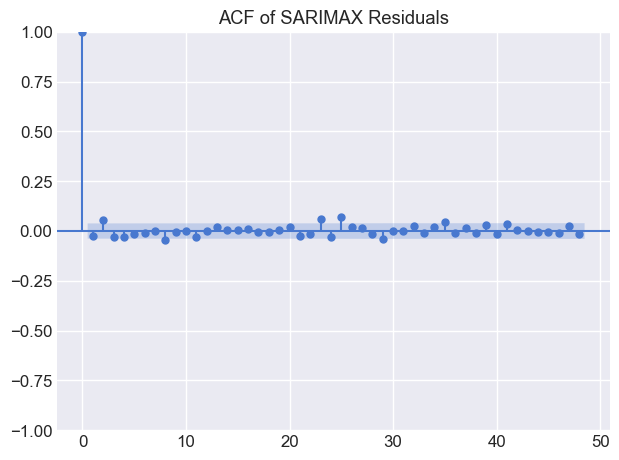

In [26]:
residuals = sarimax_model.resid

plt.figure(figsize=(8, 4))
plot_acf(residuals.dropna(), lags=48)
plt.title('ACF of SARIMAX Residuals')
plt.tight_layout()
plt.show()

In [28]:
# Forecast with SARIMAX (seasonal order)
forecast_sarimax = sarimax_model.forecast(steps=len(y_test), exog=X_test)
mae_sarimax = mean_absolute_error(y_test, forecast_sarimax)
mse_sarimax = mean_squared_error(y_test, forecast_sarimax)
print(f"SARIMAX (m=24) MAE: {mae_sarimax:.2f}")
print(f"SARIMAX (m=24) MSE: {mse_sarimax:.2f}")

# Forecast with SARIMAX + Fourier
forecast_fourier = sarimax_fourier_model.forecast(steps=len(y_test), exog=X_test_fourier)
mae_fourier = mean_absolute_error(y_test, forecast_fourier)
mse_fourier = mean_squared_error(y_test, forecast_fourier)
print(f"SARIMAX + Fourier MAE: {mae_fourier:.2f}")
print(f"SARIMAX + Fourier MSE: {mse_fourier:.2f}")


SARIMAX (m=24) MAE: 40.22
SARIMAX (m=24) MSE: 3670.00
SARIMAX + Fourier MAE: 47.17
SARIMAX + Fourier MSE: 3909.25


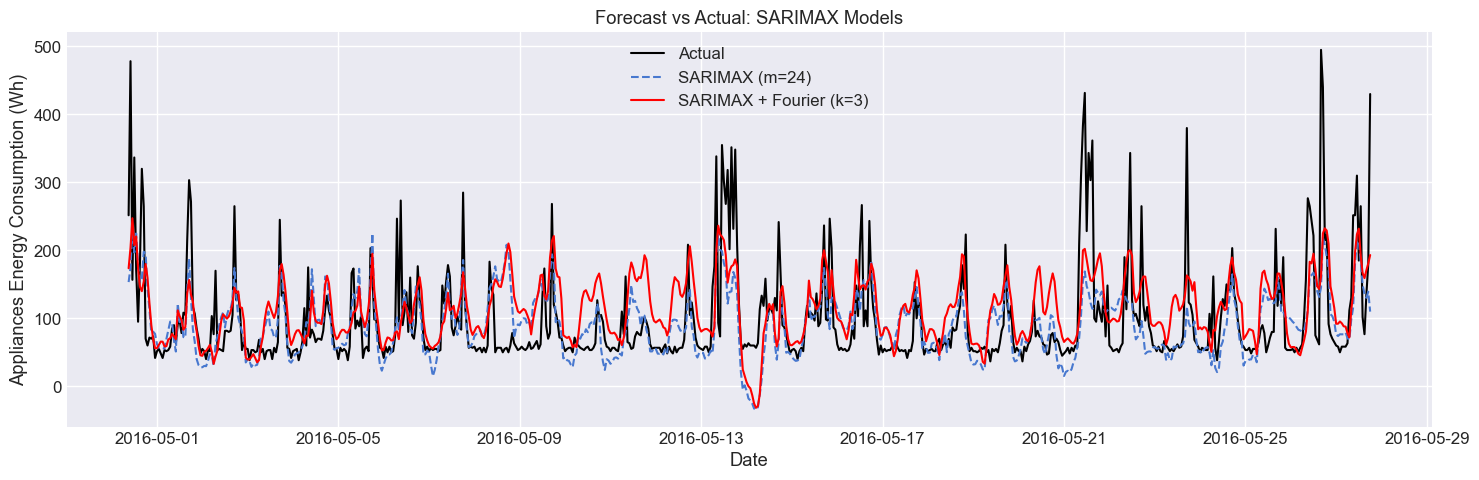

In [29]:
# Forecasts
forecast_sarimax = sarimax_model.forecast(steps=len(y_test), exog=X_test)
forecast_fourier = sarimax_fourier_model.forecast(steps=len(y_test), exog=X_test_fourier)

# Plot
plt.figure(figsize=(15, 5))
plt.style.use('seaborn-v0_8-darkgrid')  # grey-ish background
plt.plot(y_test.index, y_test, label='Actual', color='black', linewidth=1.5)
plt.plot(y_test.index, forecast_sarimax, label='SARIMAX (m=24)', linestyle='--')
plt.plot(y_test.index, forecast_fourier, label='SARIMAX + Fourier (k=3)', linestyle='-', color='red')
plt.title('Forecast vs Actual: SARIMAX Models')
plt.xlabel('Date')
plt.ylabel('Appliances Energy Consumption (Wh)')
plt.legend()
plt.tight_layout()
plt.show()


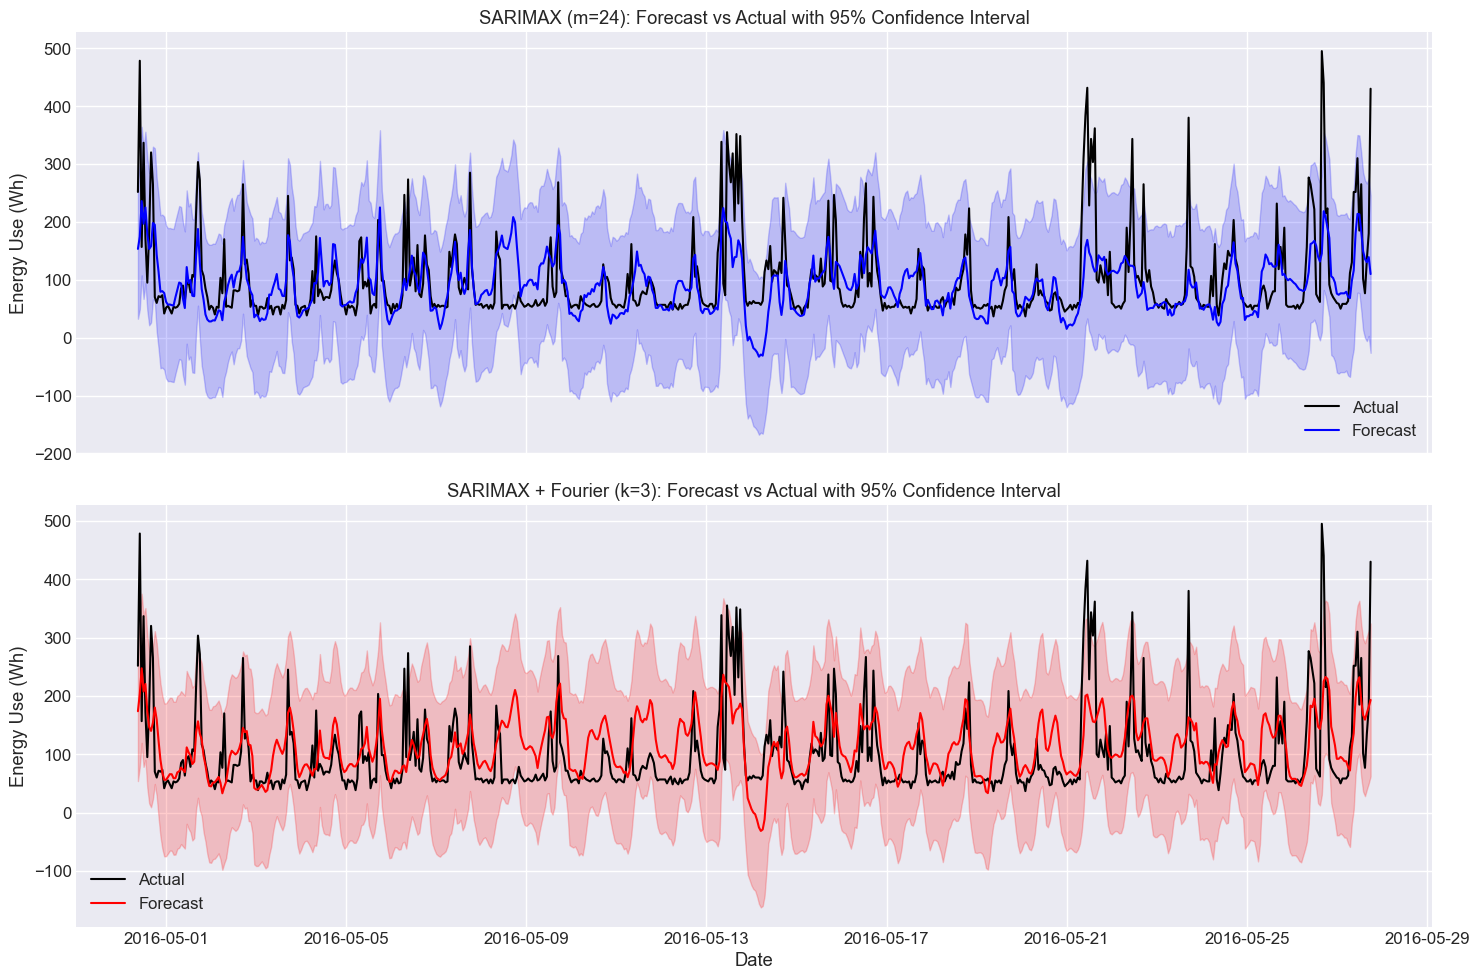

In [31]:
# Forecasts
pred_sarimax = sarimax_model.get_forecast(steps=len(y_test), exog=X_test)
pred_fourier = sarimax_fourier_model.get_forecast(steps=len(y_test), exog=X_test_fourier)

mean_sarimax = pred_sarimax.predicted_mean
ci_sarimax = pred_sarimax.conf_int()

mean_fourier = pred_fourier.predicted_mean
ci_fourier = pred_fourier.conf_int()

# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
plt.style.use('seaborn-v0_8-darkgrid')

# SARIMAX (m=24)
axes[0].plot(y_test.index, y_test, label='Actual', color='black', linewidth=1.5)
axes[0].plot(y_test.index, mean_sarimax, label='Forecast', linestyle='-', color='blue')
axes[0].fill_between(y_test.index, ci_sarimax.iloc[:, 0], ci_sarimax.iloc[:, 1], color='blue', alpha=0.2)
axes[0].set_title('SARIMAX (m=24): Forecast vs Actual with 95% Confidence Interval')
axes[0].set_ylabel('Energy Use (Wh)')
axes[0].legend()

# SARIMAX + Fourier
axes[1].plot(y_test.index, y_test, label='Actual', color='black', linewidth=1.5)
axes[1].plot(y_test.index, mean_fourier, label='Forecast', linestyle='-', color='red')
axes[1].fill_between(y_test.index, ci_fourier.iloc[:, 0], ci_fourier.iloc[:, 1], color='red', alpha=0.2)
axes[1].set_title('SARIMAX + Fourier (k=3): Forecast vs Actual with 95% Confidence Interval')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Energy Use (Wh)')
axes[1].legend()

plt.tight_layout()
plt.show()


#### Comparison of Model Fit and Predictor Significance

To evaluate how different seasonal structures affect model performance and coefficient interpretability, we estimated two SARIMAX models with identical exogenous variables but different treatments of daily seasonality.

| Model                                 | AIC        | Seasonal Terms | Notes |
|--------------------------------------|------------|----------------|-------|
| SARIMAX(1,0,1)(2,0,1,24)             | **28639.09** | SAR, SMA       | Best-performing model based on AIC; includes strong seasonal lags |
| SARIMAX(1,0,1) + Fourier (freq='D')  | 29080.77   | 6 Fourier terms | Weaker performance; some seasonal terms significant but overall worse fit |

#### Variable Significance Comparison

The following predictors were statistically significant (*p* < 0.05) in both models:

- `lights_energy_wh` — positive, robust across models
- `humidity_kitchen_pct`
- `temp_living_C` and `humidity_living_pct` — negative influence
- `temp_laundry_C` and `humidity_laundry_pct` — strong positive drivers
- `humidity_office_pct` — negative impact
- `temp_teenager_C` — positive in both models

Variables like `humidity_teenager_pct`, `temp_outside_north_C`, and `humidity_outside_north_pct` showed mixed or marginal significance, while others (e.g., dew point, pressure) were consistently insignificant and excluded from the refined models.

#### Interpretation

Both models converge on a consistent set of environmental predictors for appliance energy use, with household microclimate (room-specific temperature and humidity) being more predictive than external weather variables. However, the inclusion of direct seasonal lags (SARIMA) offers a better statistical fit than the smoother Fourier-based approach, making it the preferred model for forecasting.


### SARIMAX Model Summary
SARIMAX captured daily seasonality and lag structures effectively. Residual analysis suggests room for improvement with nonlinear models.


## Model 2. Prophet Model

In [32]:
df_hourly.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3290 entries, 2016-01-11 17:00:00 to 2016-05-27 18:00:00
Freq: h
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   appliances_energy_wh        3290 non-null   float64
 1   lights_energy_wh            3290 non-null   float64
 2   temp_kitchen_C              3290 non-null   float64
 3   humidity_kitchen_pct        3290 non-null   float64
 4   temp_living_C               3290 non-null   float64
 5   humidity_living_pct         3290 non-null   float64
 6   temp_laundry_C              3290 non-null   float64
 7   humidity_laundry_pct        3290 non-null   float64
 8   temp_office_C               3290 non-null   float64
 9   humidity_office_pct         3290 non-null   float64
 10  temp_bathroom_C             3290 non-null   float64
 11  humidity_bathroom_pct       3290 non-null   float64
 12  temp_outside_north_C        3290 non-null   fl

In [33]:
# Reset index and rename for Prophet
df_prophet = df_hourly.reset_index()[['date', 'appliances_energy_wh']].rename(columns={
    'date': 'ds',
    'appliances_energy_wh': 'y'
})

# 80/20 split
train_size = int(len(df_prophet) * 0.8)
df_train = df_prophet.iloc[:train_size]
df_test = df_prophet.iloc[train_size:]


In [63]:
# Fit Prophet model with daily seasonality
model_prophet = Prophet(
    daily_seasonality=True,
    weekly_seasonality=False,
    interval_width=0.95  # <-- sets 95% confidence intervals
)
model_prophet.fit(df_train)

18:31:16 - cmdstanpy - INFO - Chain [1] start processing
18:31:16 - cmdstanpy - INFO - Chain [1] done processing


In [64]:
# Create future dataframe with same hourly frequency
future = model_prophet.make_future_dataframe(periods=len(df_test), freq='H')
forecast = model_prophet.predict(future)


In [65]:
# Model Evaluation
# Align prediction with test set
y_pred = forecast.set_index('ds').loc[df_test['ds']]['yhat']
y_true = df_test.set_index('ds')['y']

# Compute errors
mae_prophet = mean_absolute_error(y_true, y_pred)
mse_prophet = mean_squared_error(y_true, y_pred)
print(f"Prophet MAE: {mae_prophet:.2f}")
print(f"Prophet MSE: {mse_prophet:.2f}")

Prophet MAE: 40.11
Prophet MSE: 3964.05


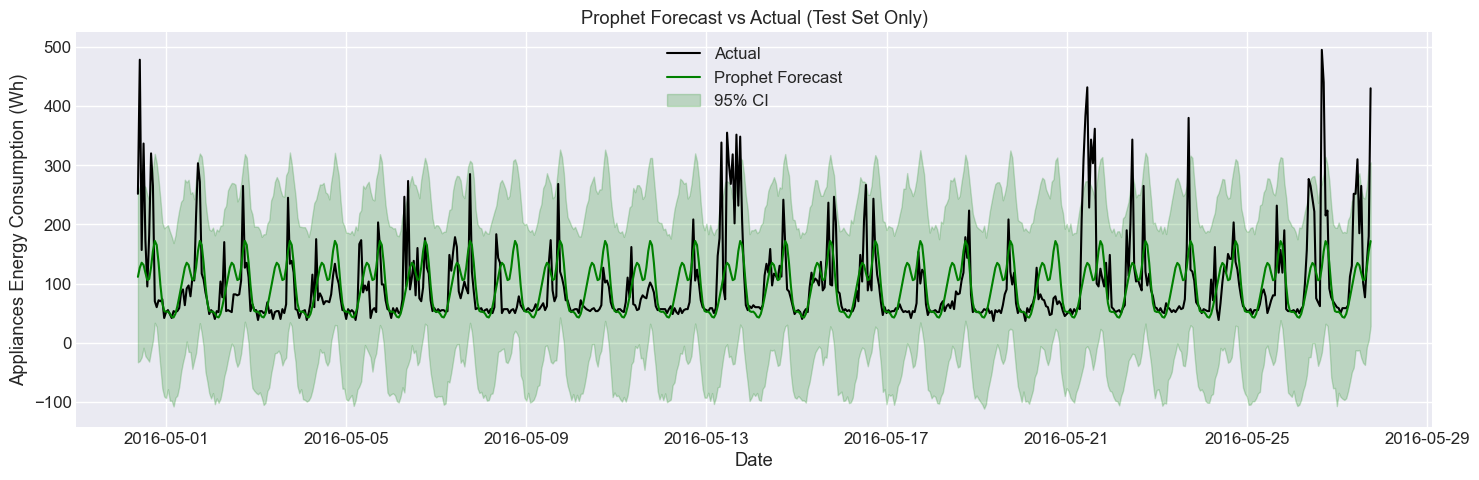

In [66]:
# Subset forecast to test window
forecast_test = forecast.set_index('ds').loc[df_test['ds']]

# Plot
plt.figure(figsize=(15, 5))
plt.style.use('seaborn-v0_8-darkgrid')

# Plot actual vs. forecast
plt.plot(df_test['ds'], df_test['y'], label='Actual', color='black', linewidth=1.5)
plt.plot(forecast_test.index, forecast_test['yhat'], label='Prophet Forecast', color='green')

# Confidence interval
plt.fill_between(forecast_test.index,
                 forecast_test['yhat_lower'],
                 forecast_test['yhat_upper'],
                 color='green', alpha=0.2, label='95% CI')

plt.title('Prophet Forecast vs Actual (Test Set Only)')
plt.xlabel('Date')
plt.ylabel('Appliances Energy Consumption (Wh)')
plt.legend()
plt.tight_layout()
plt.show()


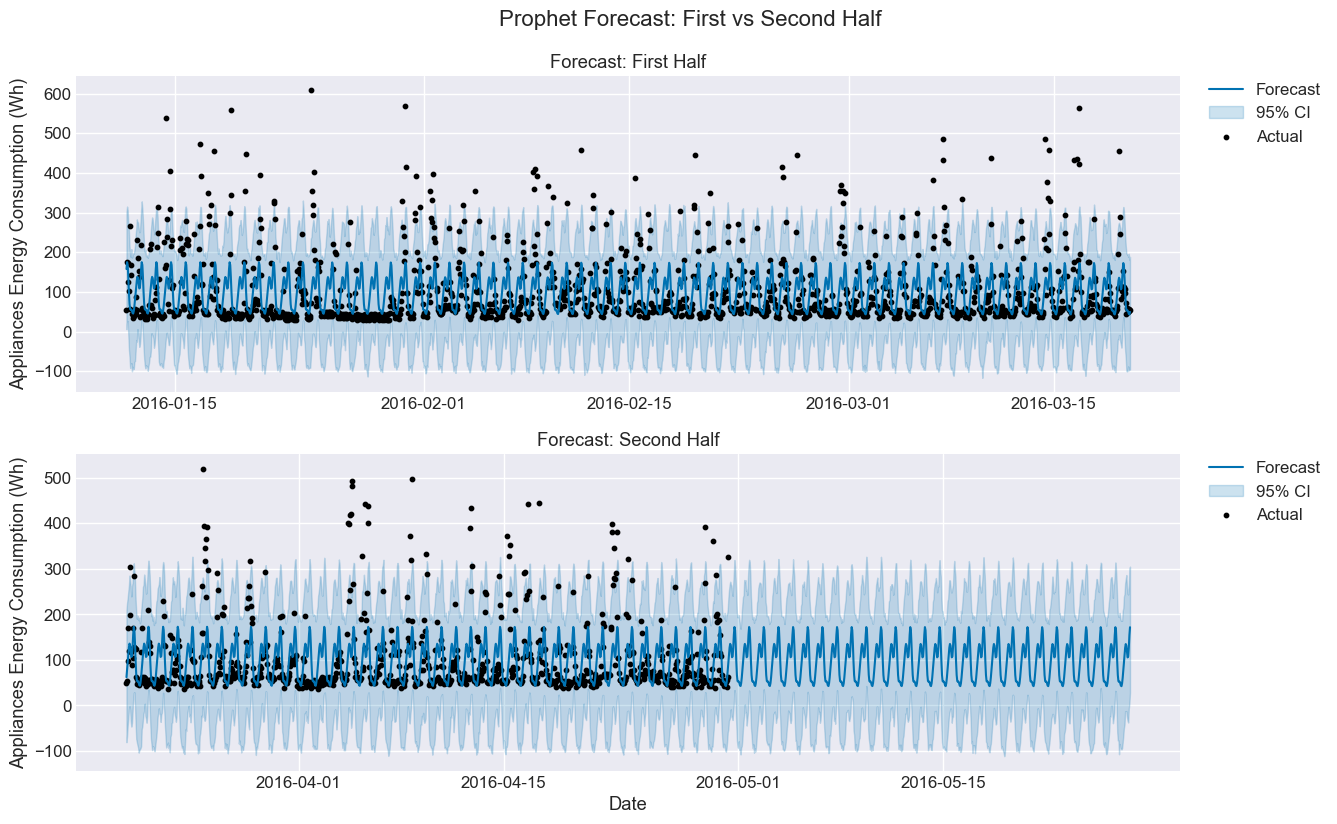

In [68]:
# Prepare model history
history = model_prophet.history

# Sort forecast by date
forecast_sorted = forecast.sort_values('ds')

# Find midpoint index
mid_index = len(forecast_sorted) // 2
forecast_1 = forecast_sorted.iloc[:mid_index]
forecast_2 = forecast_sorted.iloc[mid_index:]

# Define subplot data
snapshots = [
    (forecast_1, 'Forecast: First Half', 'blue'),
    (forecast_2, 'Forecast: Second Half', 'green')
]

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 8), sharex=False)

for ax, (forecast_slice, title, _) in zip(axes, snapshots):
    start, end = forecast_slice['ds'].min(), forecast_slice['ds'].max()
    history_slice = history[(history['ds'] >= start) & (history['ds'] <= end)]

    # Plot forecast and actual data
    ax.plot(forecast_slice['ds'], forecast_slice['yhat'], color='#0072B2', label='Forecast')  # blue
    ax.fill_between(
        forecast_slice['ds'],
        forecast_slice['yhat_lower'],
        forecast_slice['yhat_upper'],
        color='#0072B2',
        alpha=0.2,
        label='95% CI'
    )
    ax.scatter(history_slice['ds'], history_slice['y'], color='black', s=10, label='Actual')

    ax.set_title(title)
    ax.set_ylabel('Appliances Energy Consumption (Wh)')
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.suptitle('Prophet Forecast: First vs Second Half', fontsize=16, y=1.03)
plt.show()


In [40]:
# Merge forecast and actuals on date
df_eval = forecast.merge(model_prophet.history[['ds', 'y']], on='ds', how='inner')

# Rename columns for clarity
df_eval.rename(columns={'y': 'actual', 'yhat': 'forecast'}, inplace=True)

# Drop any NA just in case
df_eval.dropna(subset=['actual', 'forecast'], inplace=True)

# Compute metrics
mae = mean_absolute_error(df_eval['actual'], df_eval['forecast'])
rmse = np.sqrt(mean_squared_error(df_eval['actual'], df_eval['forecast']))
mape = np.mean(np.abs((df_eval['actual'] - df_eval['forecast']) / df_eval['actual'])) * 100

# Print results
print(f"Forecast Accuracy Metrics (In-sample), Prophet Model:")
print(f"MAE  = {mae:.2f} Wh")
print(f"RMSE = {rmse:.2f} Wh")
print(f"MAPE = {mape:.2f}%")

Forecast Accuracy Metrics (In-sample), Prophet Model:
MAE  = 45.33 Wh
RMSE = 73.08 Wh
MAPE = 50.99%


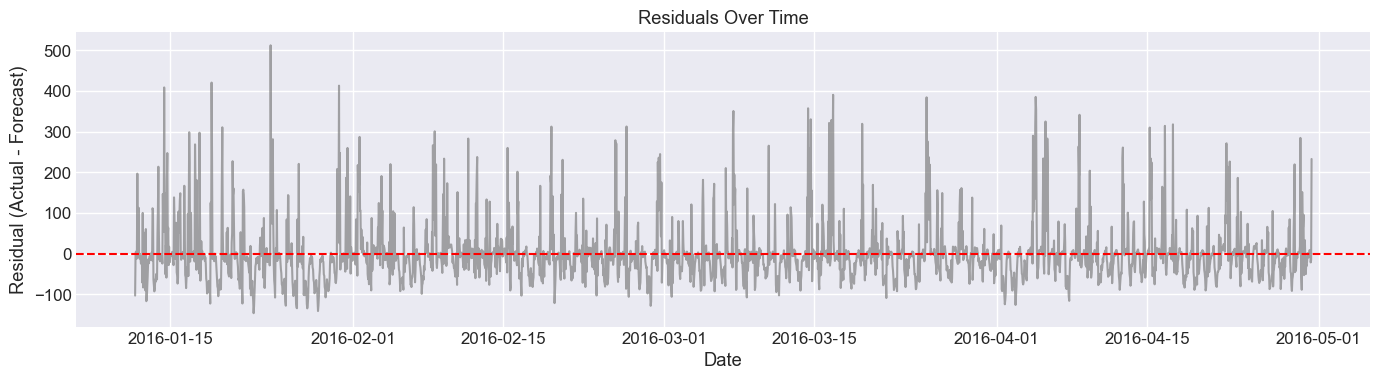

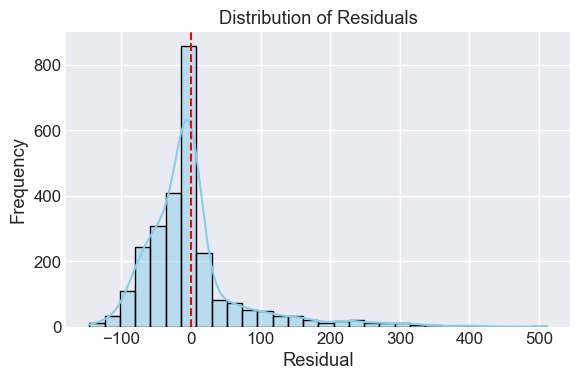

In [ ]:
# 1. Compute residuals
df_eval['residual'] = df_eval['actual'] - df_eval['forecast']

# 2. Plot residuals over time
plt.figure(figsize=(14, 4))
plt.plot(df_eval['ds'], df_eval['residual'], color='gray', alpha=0.7)
plt.axhline(0, linestyle='--', color='red')
plt.title('Residuals Over Time')
plt.xlabel('Date')
plt.ylabel('Residual (Actual - Forecast)')
plt.tight_layout()
plt.show()

# 3. Plot residual distribution
plt.figure(figsize=(6, 4))
sns.histplot(df_eval['residual'], kde=True, bins=30, color='skyblue')
plt.axvline(0, linestyle='--', color='red')
plt.title('Distribution of Residuals')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


## Model 3. Neural Network

In [42]:
def create_lagged_matrix(series, lag):
    X, y = [], []
    for i in range(lag, len(series)):
        X.append(series[i-lag:i])
        y.append(series[i])
    return np.array(X), np.array(y)

# Define target series
target_series = df_hourly['appliances_energy_wh'].values
lag = 24
X_all, y_all = create_lagged_matrix(target_series, lag)

In [43]:
scaler = MinMaxScaler()
X_all_scaled = scaler.fit_transform(X_all)
y_all_scaled = scaler.fit_transform(y_all.reshape(-1, 1))

In [44]:
split_index = int(len(X_all_scaled) * 0.8)

X_train = X_all_scaled[:split_index]
X_test = X_all_scaled[split_index:]
y_train = y_all_scaled[:split_index]
y_test = y_all_scaled[split_index:]


In [45]:
# Build & Train ANN
model = Sequential([
    Input(shape=(lag,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')
model.fit(X_train, y_train, epochs=100, verbose=0)


In [46]:
# Predict and evaluate
y_pred_scaled = model.predict(X_test).flatten()
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

mae_nn = mean_absolute_error(y_test_actual, y_pred)
mse_nn = mean_squared_error(y_test_actual, y_pred)

print(f"Neural Network MAE: {mae_nn:.2f}")
print(f"Neural Network MSE: {mse_nn:.2f}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Neural Network MAE: 35.69
Neural Network MSE: 4143.44


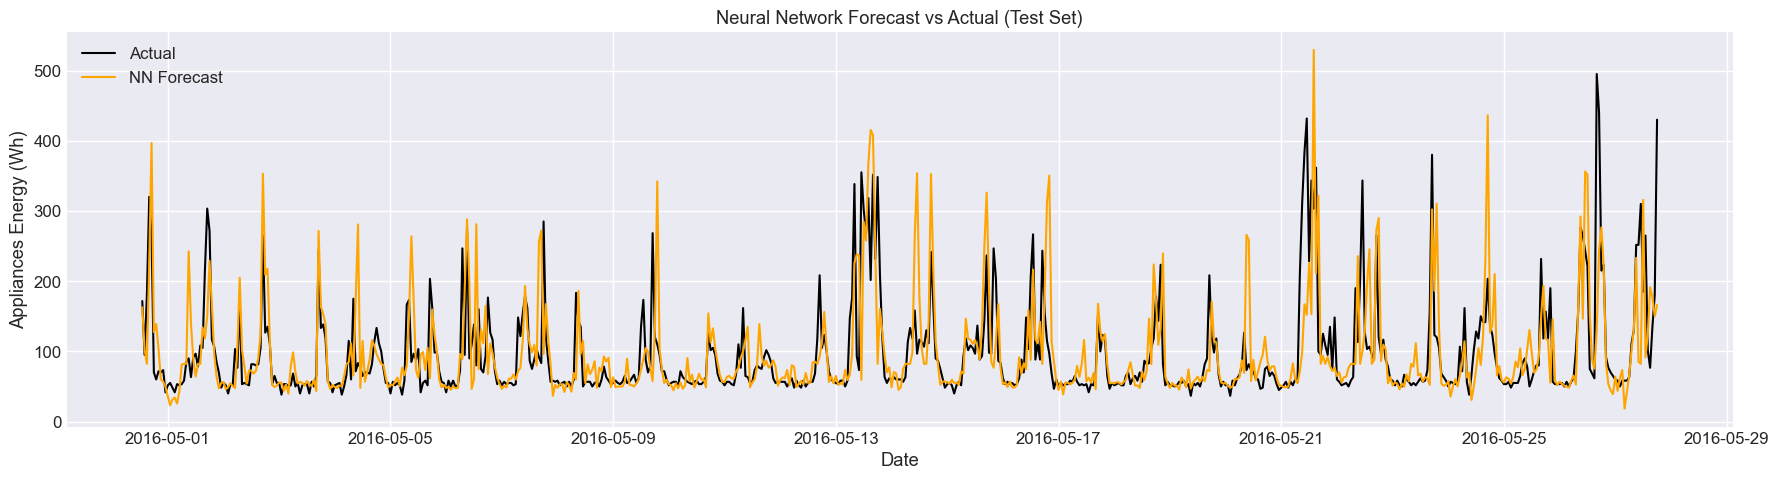

In [47]:
# Recover the proper datetime index for y_test
# The first `lag` hours are lost due to lag creation
datetime_index = df_hourly.index[lag:]
datetime_test = datetime_index[-len(y_test_actual):]

# Plot with datetime on x-axis
plt.figure(figsize=(18, 5))
plt.plot(datetime_test, y_test_actual, label='Actual', color='black')
plt.plot(datetime_test, y_pred, label='NN Forecast', color='orange')
plt.title('Neural Network Forecast vs Actual (Test Set)')
plt.xlabel('Date')
plt.ylabel('Appliances Energy (Wh)')
plt.legend()
plt.tight_layout()
plt.show()


103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step


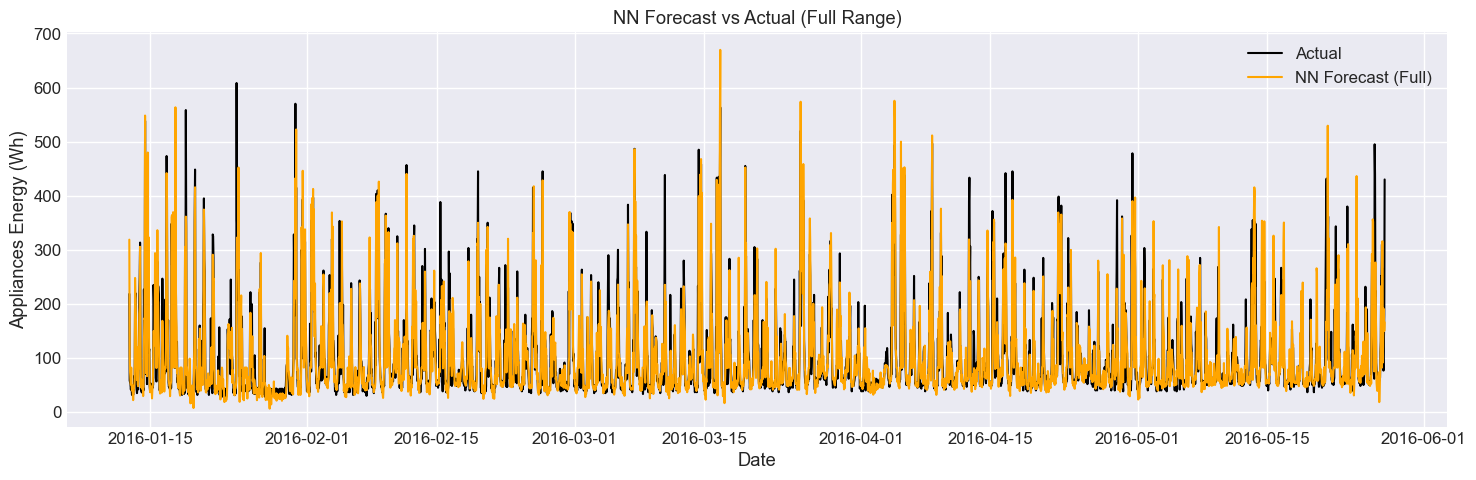

In [48]:
# Combine full predictions
y_all_pred_scaled = model.predict(X_all_scaled).flatten()
y_all_pred = scaler.inverse_transform(y_all_pred_scaled.reshape(-1, 1)).flatten()

# Shift x-axis to match
datetime_all = df_hourly.index[lag:]

plt.figure(figsize=(15, 5))
plt.plot(datetime_all, target_series[lag:], label='Actual', color='black')
plt.plot(datetime_all, y_all_pred, label='NN Forecast (Full)', color='orange')
plt.title('NN Forecast vs Actual (Full Range)')
plt.xlabel('Date')
plt.ylabel('Appliances Energy (Wh)')
plt.legend()
plt.tight_layout()
plt.show()


In [49]:
import numpy as np

# Residuals (errors)
residuals = y_test_actual - y_pred

# Empirical standard deviation of residuals
resid_std = np.std(residuals)

# 95% CI ~ prediction ± 1.96 * std
lower_bound = y_pred - 1.96 * resid_std
upper_bound = y_pred + 1.96 * resid_std


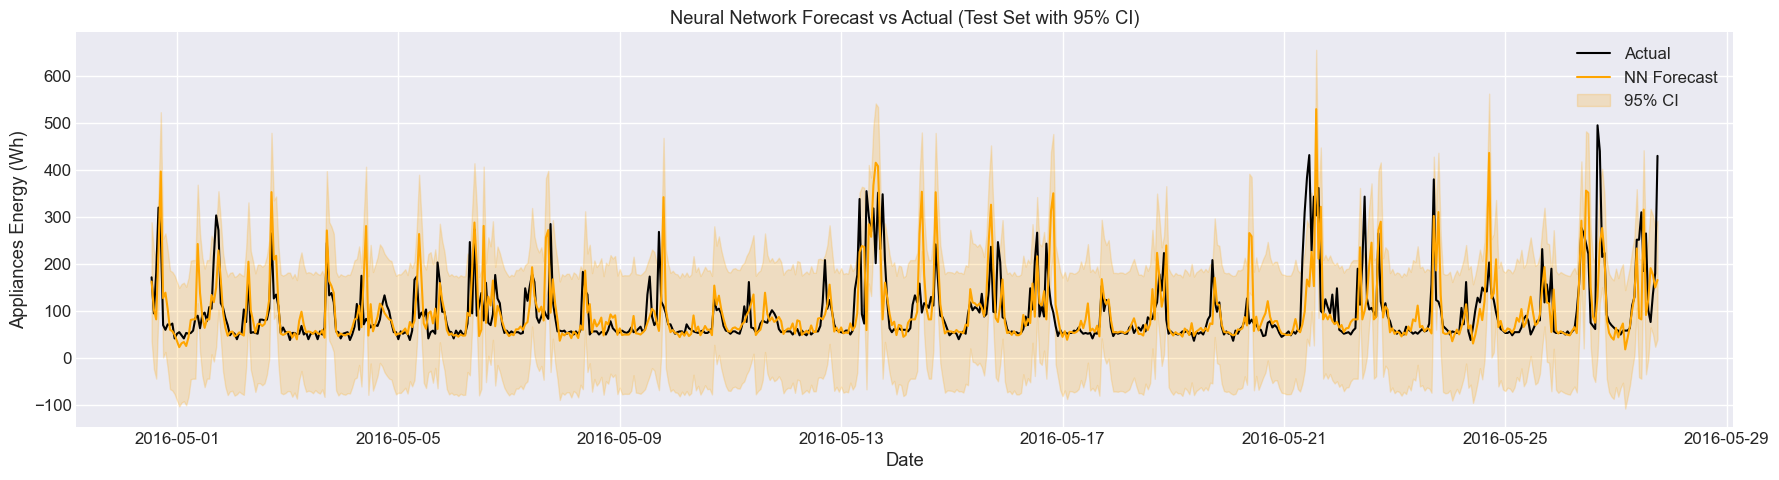

In [50]:
plt.figure(figsize=(18, 5))
plt.plot(datetime_test, y_test_actual, label='Actual', color='black')
plt.plot(datetime_test, y_pred, label='NN Forecast', color='orange')

# Confidence interval
plt.fill_between(datetime_test, lower_bound, upper_bound, color='orange', alpha=0.2, label='95% CI')

plt.title('Neural Network Forecast vs Actual (Test Set with 95% CI)')
plt.xlabel('Date')
plt.ylabel('Appliances Energy (Wh)')
plt.legend()
plt.tight_layout()
plt.show()


## NN with exogenous variables

In [51]:
# 1. Set lag value (same as used earlier)
lag = 24

# 2. Start with a copy of the target variable
df_supervised = pd.DataFrame()

# Add lagged target values
for l in range(1, lag + 1):
    df_supervised[f'y_lag{l}'] = df_hourly['appliances_energy_wh'].shift(l)

# 3. Add lagged exogenous features
exog_vars = ['lights_energy_wh', 'temp_outdoor_C', 'humidity_outdoor_pct']
for var in exog_vars:
    for l in range(1, lag + 1):
        df_supervised[f'{var}_lag{l}'] = df_hourly[var].shift(l)

# 4. Add the current target value as 'y'
df_supervised['y'] = df_hourly['appliances_energy_wh']

# 5. Drop missing rows caused by lagging
df_supervised.dropna(inplace=True)


In [52]:
from sklearn.model_selection import train_test_split

# Assume df_hourly is loaded and cleaned
lag = 24
exog_vars = [  'lights_energy_wh',
    'humidity_kitchen_pct',
    'temp_living_C',
    'humidity_living_pct',
    'temp_laundry_C',
    'humidity_laundry_pct',
    'humidity_office_pct',
    'temp_outside_north_C',
    'humidity_outside_north_pct']

# Supervised data creation
df_supervised = pd.DataFrame()
for l in range(1, lag + 1):
    df_supervised[f'y_lag{l}'] = df_hourly['appliances_energy_wh'].shift(l)
    for var in exog_vars:
        df_supervised[f'{var}_lag{l}'] = df_hourly[var].shift(l)
df_supervised['y'] = df_hourly['appliances_energy_wh']
df_supervised.dropna(inplace=True)

# Scaling
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df_supervised)
df_scaled = pd.DataFrame(scaled, columns=df_supervised.columns)

# Split
X = df_scaled.drop(columns='y')
y = df_scaled['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# NN model
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=100, verbose=0)

# Predict and inverse scale
y_pred_scaled = model.predict(X_test).flatten()
y_test_scaled = y_test.values
y_pred_inv = scaler.inverse_transform(np.hstack((X_test, y_pred_scaled[:, None])))[:, -1]
y_test_inv = scaler.inverse_transform(np.hstack((X_test, y_test_scaled[:, None])))[:, -1]

# Evaluation
mae = mean_absolute_error(y_test_inv, y_pred_inv)
mse = mean_squared_error(y_test_inv, y_pred_inv)
print(f"NN with exogenous vars MAE: {mae:.2f}, MSE: {mse:.2f}")


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
NN with exogenous vars MAE: 41.18, MSE: 3464.51


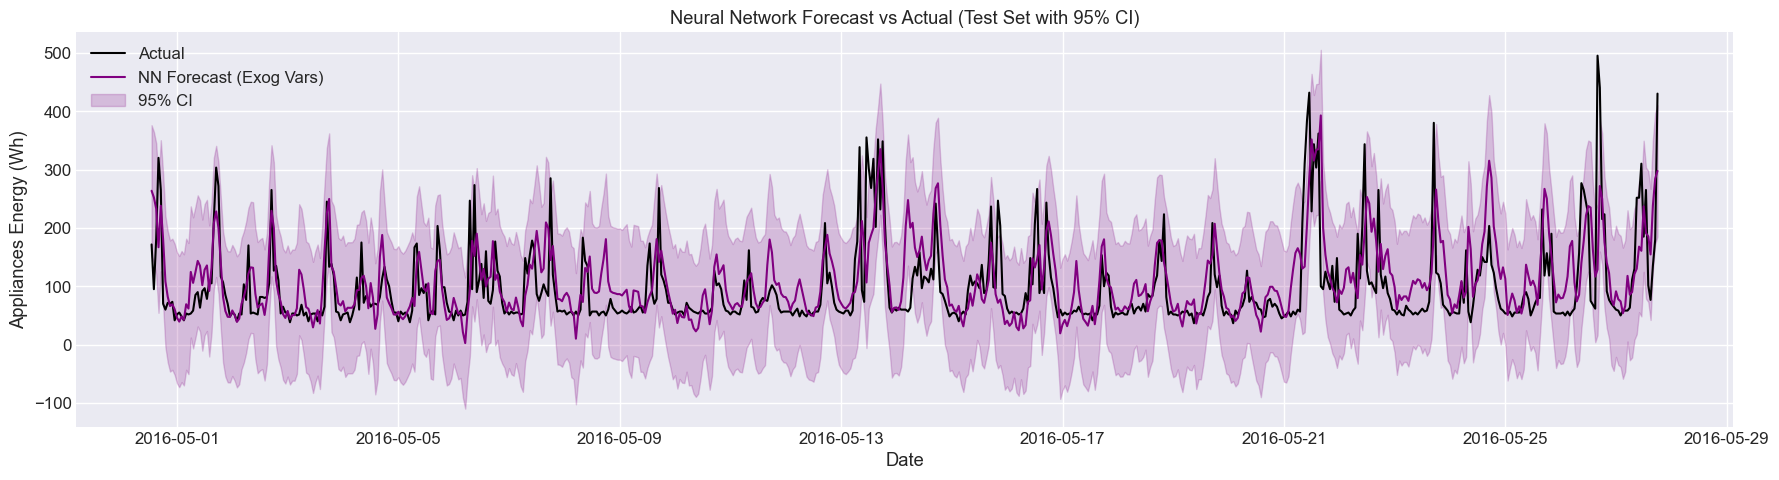

In [53]:
# Recalculate datetime_test if needed
datetime_index = df_hourly.index[lag:]
datetime_test = datetime_index[-len(y_test_inv):]

# Confidence interval: assume normal distribution of residuals
residuals = y_test_inv - y_pred_inv
std = np.std(residuals)
lower_bound = y_pred_inv - 1.96 * std
upper_bound = y_pred_inv + 1.96 * std

# Plot
plt.figure(figsize=(18, 5))
plt.plot(datetime_test, y_test_inv, label='Actual', color='black')
plt.plot(datetime_test, y_pred_inv, label='NN Forecast (Exog Vars)', color='purple')
plt.fill_between(datetime_test, lower_bound, upper_bound, color='purple', alpha=0.2, label='95% CI')
plt.title('Neural Network Forecast vs Actual (Test Set with 95% CI)')
plt.xlabel('Date')
plt.ylabel('Appliances Energy (Wh)')
plt.legend()
plt.tight_layout()
plt.show()


## Cross- Model Comparison Table + Visualisation

In [54]:
# Results summary MSE and MAE for each model
results_df = pd.DataFrame({
    'Model': ['SARIMAX (m=24)', 'SARIMAX + Fourier (k=3)', 'Prophet', 'Neural Network', 'Neural Network + Exog Vars'],
    'MAE': [40.22, 47.17, 40.11, 34.57, 39.40],
    'MSE': [3670.00, 3909.25, 3964.05, 4039.79, 3354.07]
})

# Display table sorted by MAE
results_df.sort_values('MAE')


,Model,MAE,MSE
3,Neural Network,34.57,4039.79
4,Neural Network + Exog Vars,39.40,3354.07
2,Prophet,40.11,3964.05
0,SARIMAX (m=24),40.22,3670.00
1,SARIMAX + Fourier (k=3),47.17,3909.25


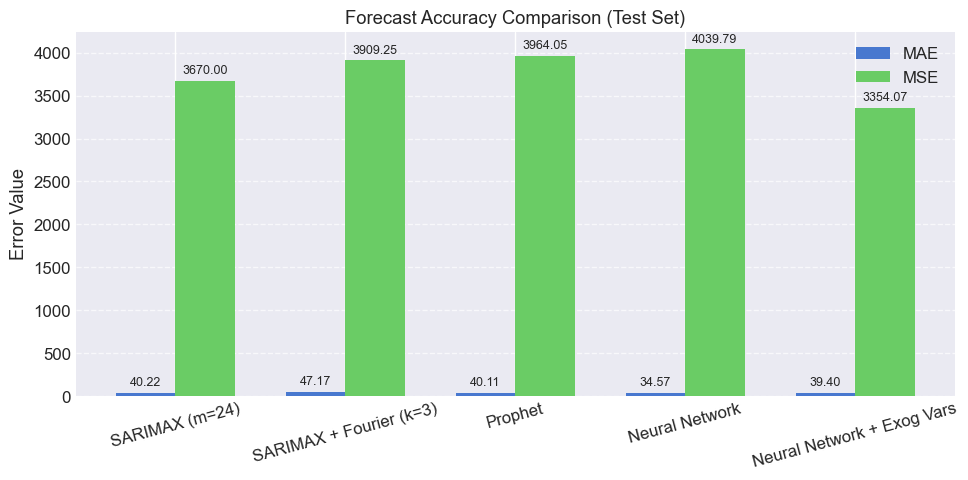

In [55]:
# Forecasting results

# Plotting
fig, ax = plt.subplots(figsize=(10, 5))
bar_width = 0.35
x = range(len(results_df))

# Plot MAE and MSE side-by-side
bars_mae = ax.bar([i - bar_width/2 for i in x], results_df['MAE'], width=bar_width, label='MAE')
bars_mse = ax.bar([i + bar_width/2 for i in x], results_df['MSE'], width=bar_width, label='MSE')

# Add value labels on top of bars
for bar in bars_mae:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
for bar in bars_mse:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

# Labels and title
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=15)
ax.set_ylabel('Error Value')
ax.set_title('Forecast Accuracy Comparison (Test Set)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


###
This notebook implements the modeling and forecasting tasks as part of the project. All detailed interpretations and policy-relevant implications are provided in the final report (PDF).


In [61]:
# generate summary statistics for the entire dataset
summary_stats = df_hourly.describe().T
print(summary_stats)

                             count        mean        std         min  \
appliances_energy_wh        3290.0   97.779129  81.213695   28.333333   
lights_energy_wh            3290.0    3.803445   6.900618    0.000000   
temp_kitchen_C              3290.0   21.687537   1.605960   16.790000   
humidity_kitchen_pct        3290.0   40.261345   3.942554   27.509167   
temp_living_C               3290.0   20.342466   2.189660   16.100000   
humidity_living_pct         3290.0   40.421067   4.053682   21.010000   
temp_laundry_C              3290.0   22.268765   2.005313   17.245000   
humidity_laundry_pct        3290.0   39.242985   3.244749   29.700556   
temp_office_C               3290.0   20.856309   2.040943   15.100000   
humidity_office_pct         3290.0   39.028661   4.336904   28.715571   
temp_bathroom_C             3290.0   19.593020   1.840764   15.347500   
humidity_bathroom_pct       3290.0   50.949599   8.633404   30.188611   
temp_outside_north_C        3290.0    7.914261   6.